# EDA
Reference prices, per-interval market snapshots, and one order book per asset.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from backtester.data_loader import build_timeline

DATA_DIR = Path('../data/validation/')
data = build_timeline(data_dir=DATA_DIR, hours=4)

print(f'ticks:      {len(data.timeline):,}')
print(f'lifecycles: {len(data.lifecycles):,}')

ref = pd.DataFrame([
    {
        'ts_sec':    t.ts_sec,
        'btc_mid':   t.btc_mid,
        'btc_cl':    t.chainlink_btc,
        'eth_mid':   t.eth_mid,
        'eth_cl':    t.chainlink_eth,
        'sol_mid':   t.sol_mid,
        'sol_cl':    t.chainlink_sol,
        'n_markets': len(t.market_prices),
    }
    for t in data.timeline
])
ref['time'] = pd.to_datetime(ref['ts_sec'], unit='s', utc=True)

print(f'ref shape: {ref.shape}')

PREFIX = {
    ('BTC', '5m'):     'btc-updown-5m',
    ('ETH', '5m'):     'eth-updown-5m',
    ('SOL', '5m'):     'sol-updown-5m',
    ('BTC', '15m'):    'btc-updown-15m',
    ('ETH', '15m'):    'eth-updown-15m',
    ('SOL', '15m'):    'sol-updown-15m',
    ('BTC', 'hourly'): 'bitcoin-up-or-down',
    ('ETH', 'hourly'): 'ethereum-up-or-down',
    ('SOL', 'hourly'): 'solana-up-or-down',
}

T0, T1 = data.timeline[0].ts_sec, data.timeline[-1].ts_sec

def pick_market(asset, interval):
    prefix = PREFIX[(asset, interval)]
    eligible = [
        lc.market_slug for lc in data.lifecycles
        if lc.interval == interval
        and lc.market_slug.startswith(prefix)
        and lc.start_ts >= T0 and lc.end_ts <= T1
    ]
    return eligible[len(eligible) // 2]

def market_series(slug):
    rows = [
        (t.ts_sec, t.market_prices[slug]['yes_price'])
        for t in data.timeline if slug in t.market_prices
    ]
    if not rows:
        return pd.Series(dtype=float, name=slug)
    ts, px = zip(*rows)
    idx = pd.to_datetime(list(ts), unit='s', utc=True)
    return pd.Series(px, index=idx, name=slug)

def asset_series(asset, interval):
    prefix = PREFIX[(asset, interval)]
    slugs = sorted(
        (lc for lc in data.lifecycles
         if lc.interval == interval and lc.market_slug.startswith(prefix)),
        key=lambda lc: lc.start_ts,
    )
    parts = [market_series(lc.market_slug) for lc in slugs]
    parts = [p for p in parts if len(p)]
    if not parts:
        return pd.Series(dtype=float)
    return pd.concat(parts).sort_index()

ref[['btc_mid', 'btc_cl', 'eth_mid', 'eth_cl', 'sol_mid', 'sol_cl', 'n_markets']].describe().round(2)

ticks:      14,401
lifecycles: 213
ref shape: (14401, 9)


,btc_mid,btc_cl,eth_mid,eth_cl,sol_mid,sol_cl,n_markets
count,14401.00,14401.00,14401.00,14401.00,14401.00,14401.00,14401.00
mean,74721.25,74837.93,2347.70,2348.08,85.27,85.33,3.60
std,80.11,153.08,6.92,6.87,1.89,0.16,1.57
min,74516.24,74531.06,2334.90,2335.34,0.00,84.93,0.00
25%,74655.50,74707.63,2341.08,2341.42,85.16,85.18,3.00
50%,74720.33,74831.12,2346.99,2347.33,85.36,85.37,3.00
75%,74799.05,74986.06,2354.16,2354.47,85.44,85.45,5.00
max,74866.80,75127.60,2360.73,2361.10,85.62,85.65,13.00


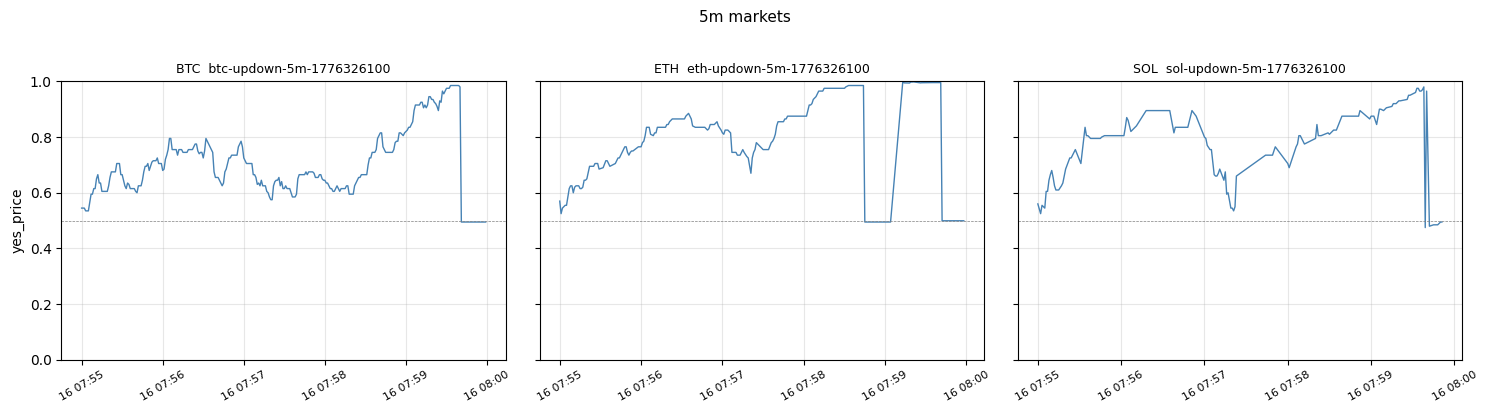

global ref describe():
        btc_mid    btc_cl   eth_mid    eth_cl   sol_mid    sol_cl  n_markets
count  14401.00  14401.00  14401.00  14401.00  14401.00  14401.00   14401.00
mean   74721.25  74837.93   2347.70   2348.08     85.27     85.33       3.60
std       80.11    153.08      6.92      6.87      1.89      0.16       1.57
min    74516.24  74531.06   2334.90   2335.34      0.00     84.93       0.00
25%    74655.50  74707.63   2341.08   2341.42     85.16     85.18       3.00
50%    74720.33  74831.12   2346.99   2347.33     85.36     85.37       3.00
75%    74799.05  74986.06   2354.16   2354.47     85.44     85.45       5.00
max    74866.80  75127.60   2360.73   2361.10     85.62     85.65      13.00

per-market yes_price describe():


,BTC,ETH,SOL
count,298.000,197.000,132.000
mean,0.702,0.806,0.775
std,0.117,0.134,0.131
min,0.495,0.495,0.475
25%,0.625,0.730,0.679
50%,0.675,0.835,0.805
75%,0.755,0.875,0.875
max,0.985,0.998,0.980


In [2]:
interval = '5m'
slugs  = {a: pick_market(a, interval) for a in ['BTC', 'ETH', 'SOL']}
series = {a: market_series(s) for a, s in slugs.items()}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, asset in zip(axes, ['BTC', 'ETH', 'SOL']):
    s = series[asset]
    ax.plot(s.index, s.values, linewidth=1, color='steelblue')
    ax.axhline(0.5, color='grey', linewidth=0.5, linestyle='--')
    ax.set_title(f'{asset}  {slugs[asset]}', fontsize=9)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', labelrotation=30, labelsize=8)
axes[0].set_ylabel('yes_price')
fig.suptitle(f'{interval} markets', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

print('global ref describe():')
print(ref[['btc_mid', 'btc_cl', 'eth_mid', 'eth_cl', 'sol_mid', 'sol_cl', 'n_markets']].describe().round(2))
print()
print('per-market yes_price describe():')
pd.DataFrame({a: series[a].describe() for a in ['BTC', 'ETH', 'SOL']}).round(3)

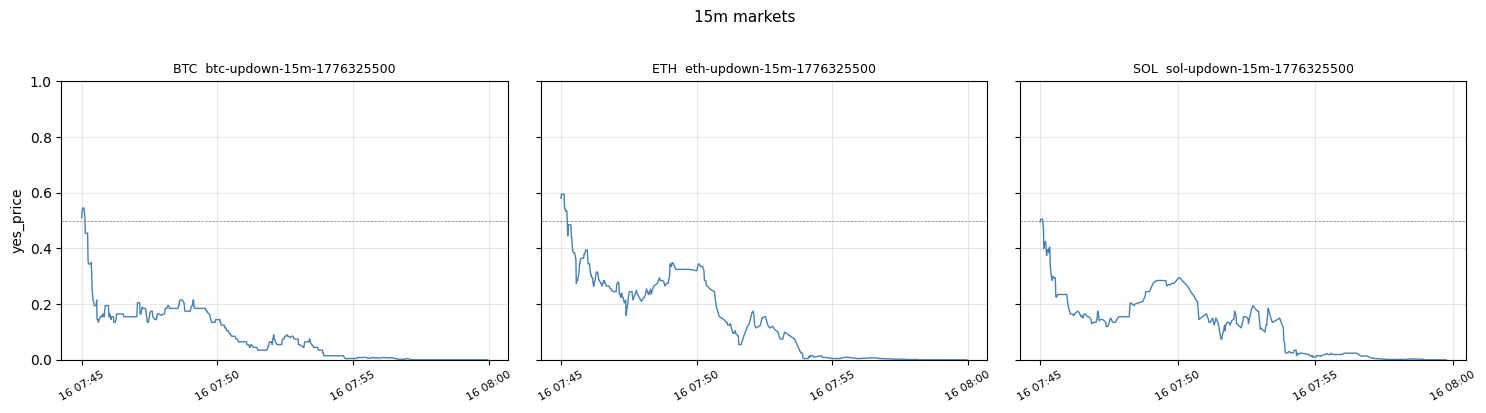

global ref describe():
        btc_mid    btc_cl   eth_mid    eth_cl   sol_mid    sol_cl  n_markets
count  14401.00  14401.00  14401.00  14401.00  14401.00  14401.00   14401.00
mean   74721.25  74837.93   2347.70   2348.08     85.27     85.33       3.60
std       80.11    153.08      6.92      6.87      1.89      0.16       1.57
min    74516.24  74531.06   2334.90   2335.34      0.00     84.93       0.00
25%    74655.50  74707.63   2341.08   2341.42     85.16     85.18       3.00
50%    74720.33  74831.12   2346.99   2347.33     85.36     85.37       3.00
75%    74799.05  74986.06   2354.16   2354.47     85.44     85.45       5.00
max    74866.80  75127.60   2360.73   2361.10     85.62     85.65      13.00

per-market yes_price describe():


,BTC,ETH,SOL
count,453.000,278.000,267.000
mean,0.115,0.219,0.147
std,0.104,0.150,0.113
min,0.000,0.000,0.000
25%,0.035,0.095,0.025
50%,0.095,0.245,0.145
75%,0.170,0.315,0.205
max,0.545,0.595,0.505


In [3]:
interval = '15m'
slugs  = {a: pick_market(a, interval) for a in ['BTC', 'ETH', 'SOL']}
series = {a: market_series(s) for a, s in slugs.items()}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, asset in zip(axes, ['BTC', 'ETH', 'SOL']):
    s = series[asset]
    ax.plot(s.index, s.values, linewidth=1, color='steelblue')
    ax.axhline(0.5, color='grey', linewidth=0.5, linestyle='--')
    ax.set_title(f'{asset}  {slugs[asset]}', fontsize=9)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', labelrotation=30, labelsize=8)
axes[0].set_ylabel('yes_price')
fig.suptitle(f'{interval} markets', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

print('global ref describe():')
print(ref[['btc_mid', 'btc_cl', 'eth_mid', 'eth_cl', 'sol_mid', 'sol_cl', 'n_markets']].describe().round(2))
print()
print('per-market yes_price describe():')
pd.DataFrame({a: series[a].describe() for a in ['BTC', 'ETH', 'SOL']}).round(3)

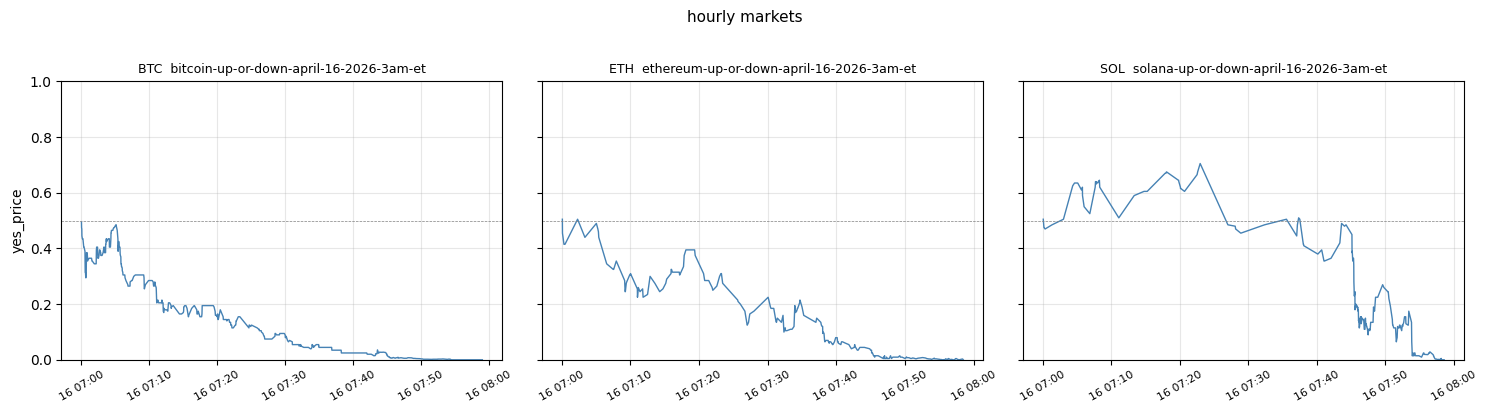

global ref describe():
        btc_mid    btc_cl   eth_mid    eth_cl   sol_mid    sol_cl  n_markets
count  14401.00  14401.00  14401.00  14401.00  14401.00  14401.00   14401.00
mean   74721.25  74837.93   2347.70   2348.08     85.27     85.33       3.60
std       80.11    153.08      6.92      6.87      1.89      0.16       1.57
min    74516.24  74531.06   2334.90   2335.34      0.00     84.93       0.00
25%    74655.50  74707.63   2341.08   2341.42     85.16     85.18       3.00
50%    74720.33  74831.12   2346.99   2347.33     85.36     85.37       3.00
75%    74799.05  74986.06   2354.16   2354.47     85.44     85.45       5.00
max    74866.80  75127.60   2360.73   2361.10     85.62     85.65      13.00

per-market yes_price describe():


,BTC,ETH,SOL
count,603.000,289.000,251.000
mean,0.164,0.117,0.239
std,0.147,0.129,0.207
min,0.000,0.000,0.000
25%,0.028,0.008,0.115
50%,0.125,0.065,0.150
75%,0.290,0.200,0.388
max,0.495,0.505,0.705


In [4]:
interval = 'hourly'
slugs  = {a: pick_market(a, interval) for a in ['BTC', 'ETH', 'SOL']}
series = {a: market_series(s) for a, s in slugs.items()}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, asset in zip(axes, ['BTC', 'ETH', 'SOL']):
    s = series[asset]
    ax.plot(s.index, s.values, linewidth=1, color='steelblue')
    ax.axhline(0.5, color='grey', linewidth=0.5, linestyle='--')
    ax.set_title(f'{asset}  {slugs[asset]}', fontsize=9)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', labelrotation=30, labelsize=8)
axes[0].set_ylabel('yes_price')
fig.suptitle(f'{interval} markets', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

print('global ref describe():')
print(ref[['btc_mid', 'btc_cl', 'eth_mid', 'eth_cl', 'sol_mid', 'sol_cl', 'n_markets']].describe().round(2))
print()
print('per-market yes_price describe():')
pd.DataFrame({a: series[a].describe() for a in ['BTC', 'ETH', 'SOL']}).round(3)

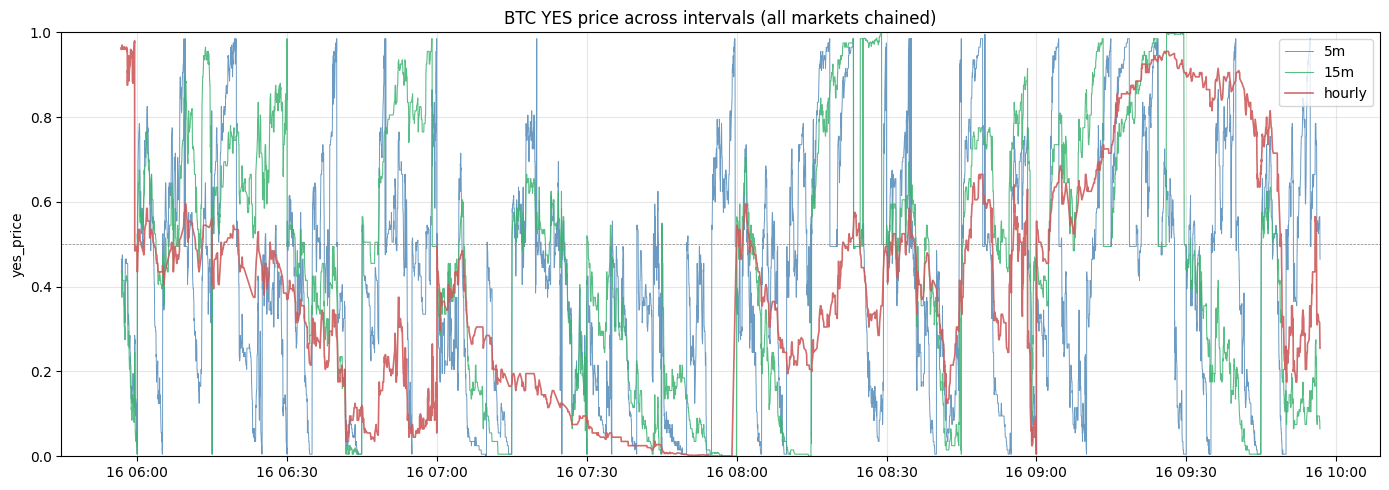

In [5]:
asset = 'BTC'
s_5m  = asset_series(asset, '5m')
s_15m = asset_series(asset, '15m')
s_1h  = asset_series(asset, 'hourly')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(s_5m.index,  s_5m.values,  label='5m',     linewidth=0.7, color='steelblue',   alpha=0.8)
ax.plot(s_15m.index, s_15m.values, label='15m',    linewidth=0.8, color='mediumseagreen', alpha=0.85)
ax.plot(s_1h.index,  s_1h.values,  label='hourly', linewidth=1.2, color='indianred',   alpha=0.9)
ax.axhline(0.5, color='grey', linewidth=0.5, linestyle='--')
ax.set_ylim(0, 1)
ax.set_ylabel('yes_price')
ax.set_title(f'{asset} YES price across intervals (all markets chained)')
ax.grid(alpha=0.3)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

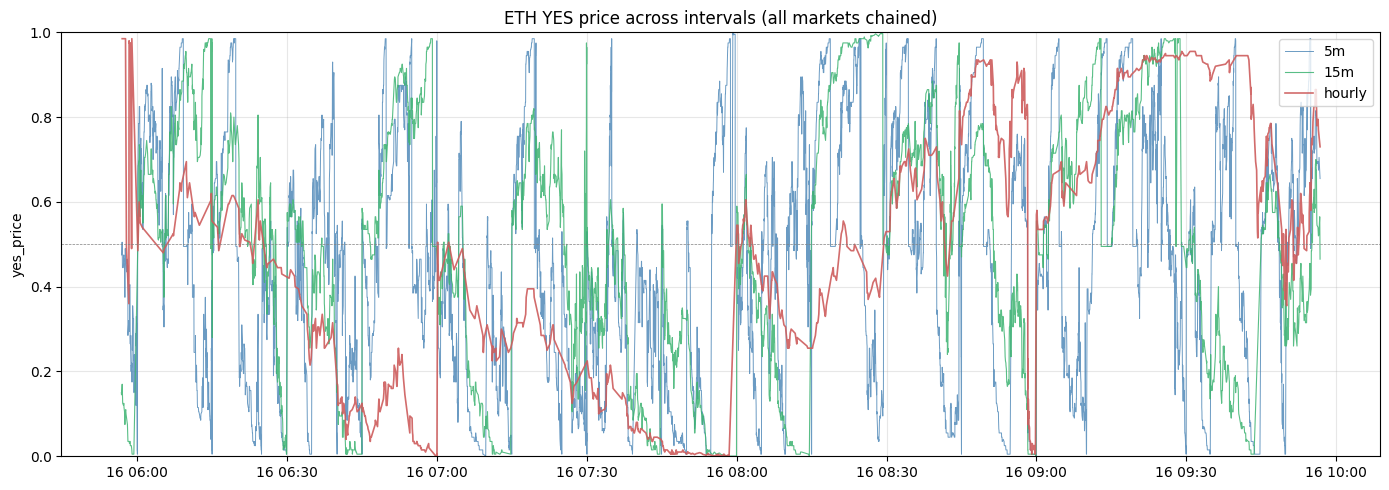

In [6]:
asset = 'ETH'
s_5m  = asset_series(asset, '5m')
s_15m = asset_series(asset, '15m')
s_1h  = asset_series(asset, 'hourly')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(s_5m.index,  s_5m.values,  label='5m',     linewidth=0.7, color='steelblue',   alpha=0.8)
ax.plot(s_15m.index, s_15m.values, label='15m',    linewidth=0.8, color='mediumseagreen', alpha=0.85)
ax.plot(s_1h.index,  s_1h.values,  label='hourly', linewidth=1.2, color='indianred',   alpha=0.9)
ax.axhline(0.5, color='grey', linewidth=0.5, linestyle='--')
ax.set_ylim(0, 1)
ax.set_ylabel('yes_price')
ax.set_title(f'{asset} YES price across intervals (all markets chained)')
ax.grid(alpha=0.3)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

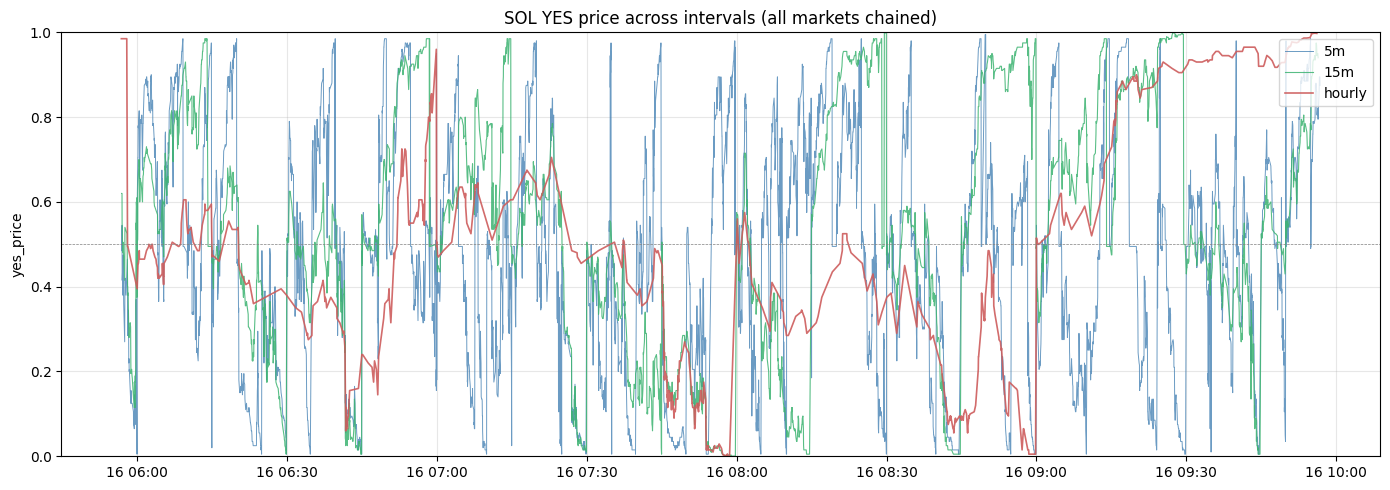

In [7]:
asset = 'SOL'
s_5m  = asset_series(asset, '5m')
s_15m = asset_series(asset, '15m')
s_1h  = asset_series(asset, 'hourly')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(s_5m.index,  s_5m.values,  label='5m',     linewidth=0.7, color='steelblue',   alpha=0.8)
ax.plot(s_15m.index, s_15m.values, label='15m',    linewidth=0.8, color='mediumseagreen', alpha=0.85)
ax.plot(s_1h.index,  s_1h.values,  label='hourly', linewidth=1.2, color='indianred',   alpha=0.9)
ax.axhline(0.5, color='grey', linewidth=0.5, linestyle='--')
ax.set_ylim(0, 1)
ax.set_ylabel('yes_price')
ax.set_title(f'{asset} YES price across intervals (all markets chained)')
ax.grid(alpha=0.3)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

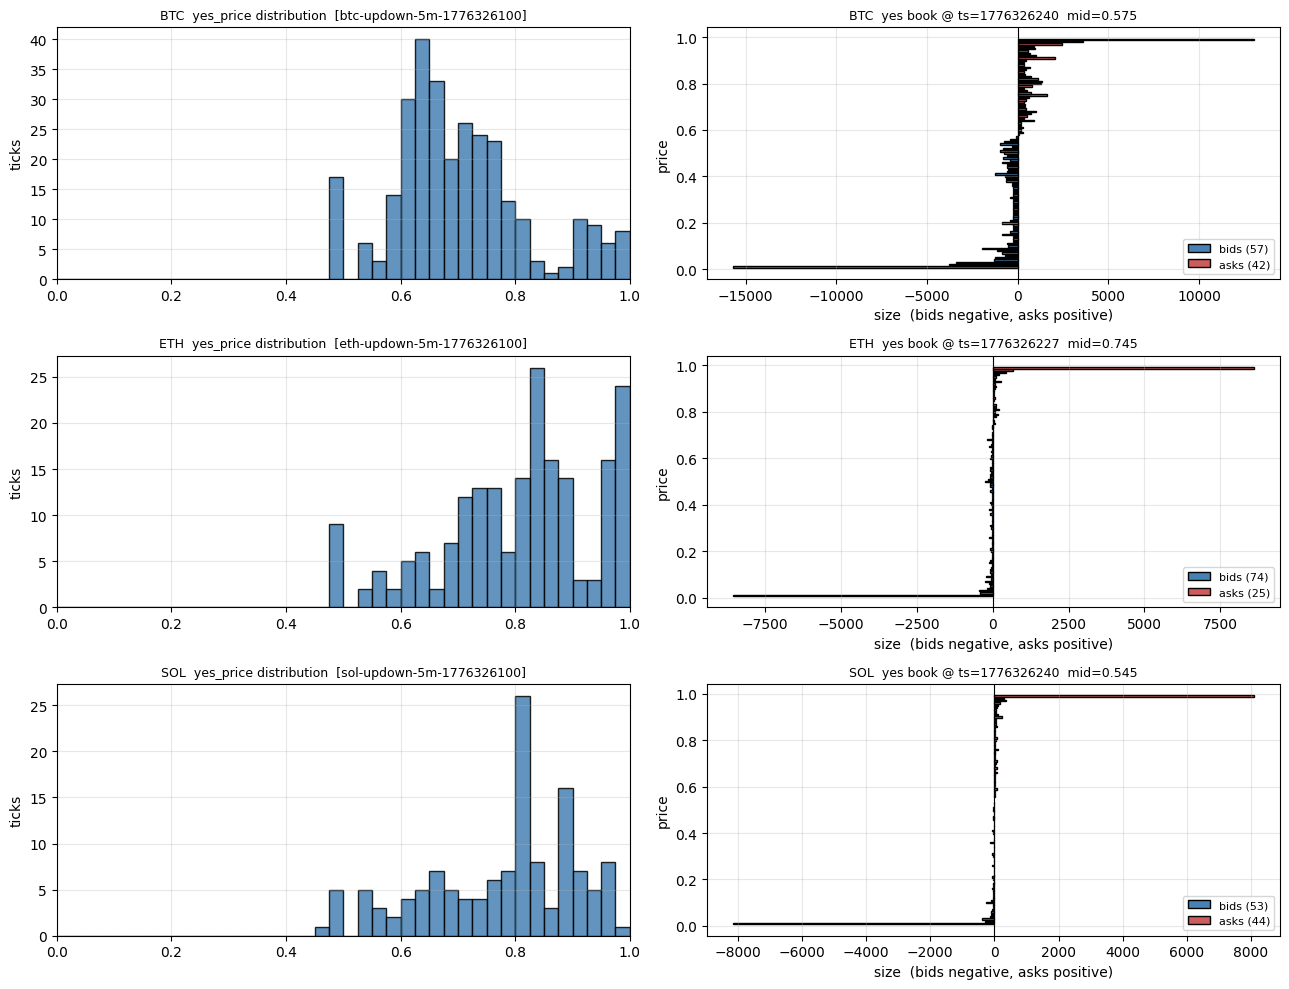

In [8]:
picks = {a: pick_market(a, '5m') for a in ['BTC', 'ETH', 'SOL']}

fig, axes = plt.subplots(3, 2, figsize=(13, 10))
for row, asset in enumerate(['BTC', 'ETH', 'SOL']):
    slug = picks[asset]
    s = market_series(slug)

    ax_h = axes[row, 0]
    ax_h.hist(s.values, bins=40, range=(0, 1), color='steelblue', edgecolor='black', alpha=0.85)
    ax_h.set_xlim(0, 1)
    ax_h.set_ylabel('ticks')
    ax_h.set_title(f'{asset}  yes_price distribution  [{slug}]', fontsize=9)
    ax_h.grid(alpha=0.3)

    ticks_with_book = [
        t for t in data.timeline
        if slug in t.order_books
        and len(t.order_books[slug].yes_book.bids) >= 1
        and len(t.order_books[slug].yes_book.asks) >= 1
    ]
    ob_tick = ticks_with_book[len(ticks_with_book) // 2]
    book = ob_tick.order_books[slug].yes_book

    bid_prices = [lvl.price for lvl in book.bids]
    bid_sizes  = [-lvl.size for lvl in book.bids]
    ask_prices = [lvl.price for lvl in book.asks]
    ask_sizes  = [lvl.size  for lvl in book.asks]

    ax_b = axes[row, 1]
    ax_b.barh(bid_prices, bid_sizes, color='steelblue', edgecolor='black',
              height=0.006, label=f'bids ({len(bid_prices)})')
    ax_b.barh(ask_prices, ask_sizes, color='indianred', edgecolor='black',
              height=0.006, label=f'asks ({len(ask_prices)})')
    ax_b.axvline(0, color='black', linewidth=0.8)
    ax_b.set_xlabel('size  (bids negative, asks positive)')
    ax_b.set_ylabel('price')
    ax_b.set_title(f'{asset}  yes book @ ts={ob_tick.ts_sec}  mid={book.mid:.3f}', fontsize=9)
    ax_b.grid(alpha=0.3)
    ax_b.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()